# Task 1 — Dataset Selection and Relevance: Household Electric Power Consumption

**Author:** Deepakkumar Govindan (s225234246) — Models sub-team
**Branch:** `deepak/report/household-power`
**Location in repo:** `data_science/datasets/household-power/`

This notebook will continue into the Task 2 full data-quality analysis. This section covers Task 1's dataset selection and relevance justification.


## Dataset Selection and Relevance

### Dataset name and source
**Individual Household Electric Power Consumption**, from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption) (public domain, no login required).

### Domain / topic
Residential energy / smart-meter monitoring — a different domain from the seismic, wearable, and farming datasets other team members are exploring, while still being a realistic multi-sensor IoT time series.

### Why it was selected
- It is real smart-meter telemetry, not synthetic or lab-generated data, from a single household in Sceaux, France, logged **minute-by-minute from December 2006 to November 2010** (~4 years, 2,075,259 readings).
- It contains **genuine, undoctored data-quality problems** — missing readings and multi-day outages — which is exactly the kind of realistic imperfection we need to prove our pipeline works outside NAB's cleaner benchmark data.
- It has **multiple correlated numeric channels** from the same meter (see below), giving us a real basis to test AIntl's cross-variable correlation logic, not just single-series anomaly detection.
- It is well documented, easy to re-obtain, and large enough to be meaningful while still being practical to work with locally.

### Main variables available
| Variable | Description |
|---|---|
| `datetime` | Minute-level timestamp |
| `Global_active_power` | Total real power consumed (kW) |
| `Global_reactive_power` | Total reactive power (kVAR) |
| `Voltage` | Mains voltage (V) |
| `Global_intensity` | Total current intensity (A) |
| `Sub_metering_1` | Kitchen circuit (Wh) |
| `Sub_metering_2` | Laundry room circuit (Wh) |
| `Sub_metering_3` | Water-heater / air-conditioner circuit (Wh) |

**Timestamps:** yes — a continuous minute-level `datetime` index spanning ~4 years.

**Numeric variables suitable for anomaly analysis:** yes — all seven measurement columns above are continuous numeric readings suitable for point- and sequence-level anomaly detection (spikes, gaps, drift).

**Two or more variables useful for correlation:** yes. `Global_active_power` should track closely with `Global_intensity` and the sum of the three sub-metering channels under normal conditions; `Voltage` should stay roughly stable regardless of load. This gives AIntl real relationships to test — e.g. does total power still correlate with current draw during an anomalous spike, or does sub-metering diverge from the global reading during a fault/outage?

### Suitability for the IoT Analytics MVP
Suitable. It is a genuine multi-channel, timestamped IoT-style stream from a single physical device, structurally identical to what the Models/AIntl pipeline is built to ingest (timestamp + numeric sensor readings), and it is large and messy enough to be a meaningful test of the pipeline outside the controlled NAB dataset.

### Expected anomaly / unusual-behaviour types
- **Missing-data gaps** — dropped minutes and full-day outages (a real device going offline), the kind of thing the input validator's missing-value checks and LevelShiftAD/gap-detection logic should catch.
- **Point anomalies / spikes** — unusually high power draw (e.g. evening heating load), testable with QuantileAD, ECOD, COPOD, Isolation Forest.
- **Cross-variable inconsistency** — a case where `Global_active_power` and `Global_intensity` no longer move together, or where the sum of sub-metering channels diverges sharply from the global reading — a candidate scenario for AIntl's correlation-based detection.


---
## Preliminary Exploration

Light exploration only — confirms the dataset is accessible locally and has the expected shape. Full data-quality analysis belongs in Task 2.


In [1]:
import pandas as pd

hourly = pd.read_csv("data/household_power_hourly.csv", parse_dates=["datetime"], index_col="datetime")
daily_missing = pd.read_csv("data/household_power_daily_missing.csv", parse_dates=["datetime"], index_col="datetime")

print(hourly.shape, daily_missing.shape)
hourly.head()

(34589, 7) (1442, 1)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [2]:
hourly.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000
mean,1.091728,0.123727,240.839393,4.628238,1.121631,1.298566,6.458882
std,0.897619,0.066851,3.001093,3.757797,3.538046,4.192874,7.351219
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.341925,0.078000,239.180667,1.513333,0.000000,0.000000,0.650000
50%,0.802850,0.106917,240.977833,3.423333,0.000000,0.333333,1.650000
75%,1.579342,0.149433,242.695000,6.606667,0.000000,0.650000,14.216667
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000


### Quick look: missing-data gaps

In [3]:
worst_days = daily_missing.sort_values("missing_minutes", ascending=False).head(10)
worst_days

,missing_minutes
datetime,
2010-09-27,1440
2007-04-29,1440
2010-09-26,1440
2010-08-21,1440
2010-08-20,1440
2010-08-19,1440
2009-06-14,1440
2010-08-18,1440
2010-01-13,1440


### Quick look: consumption spikes

In [4]:
q999 = hourly['Global_active_power'].quantile(0.999)
spikes = hourly[hourly['Global_active_power'] > q999].sort_values('Global_active_power', ascending=False)
print(f"99.9th percentile hourly draw: {q999:.2f} kW")
print(f"Number of hours above it: {len(spikes)}")
spikes[['Global_active_power']].head(10)

99.9th percentile hourly draw: 5.17 kW
Number of hours above it: 35


,Global_active_power
datetime,
2008-11-23 18:00:00,6.560533
2009-01-16 20:00:00,6.519633
2008-02-02 19:00:00,6.496033
2007-12-23 19:00:00,6.488000
2007-02-22 21:00:00,6.363867
2007-12-28 17:00:00,6.333667
2008-11-23 20:00:00,6.310567
2007-01-21 20:00:00,6.076567
2008-01-26 19:00:00,6.013800


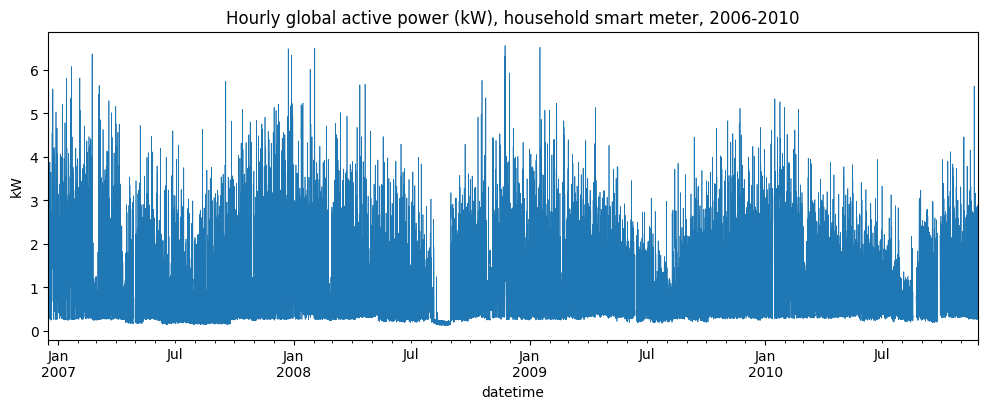

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
hourly['Global_active_power'].plot(ax=ax, linewidth=0.5)
ax.set_title("Hourly global active power (kW), household smart meter, 2006-2010")
ax.set_ylabel("kW")
plt.show()

### Quick look: correlation potential

In [6]:
hourly[['Global_active_power','Global_intensity','Voltage']].corr()

,Global_active_power,Global_intensity,Voltage
Global_active_power,1.000000,0.999423,-0.379450
Global_intensity,0.999423,1.000000,-0.392769
Voltage,-0.379450,-0.392769,1.000000


## Definition of Done — status

- [x] Dataset obtained and accessible locally (`data/household_power_hourly.csv`, `data/household_power_daily_missing.csv`)
- [x] Source/provenance recorded (UCI ML Repository, dataset 235)
- [x] Contains suitable time-series/numeric information (7 numeric channels, minute-level timestamps)
- [x] Relevance to anomaly detection, AIntl, and the MVP justified above
- [ ] Full data-quality analysis — **Task 2**
